R-squared: 0.9755
공부 시간 3.8시간에 대한 예측 성적: 50.7


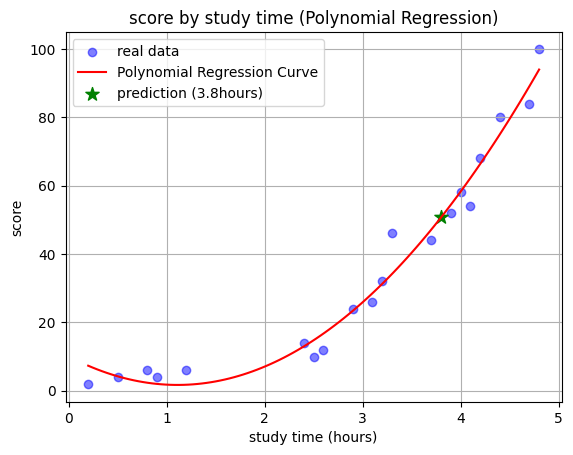

In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# CSV 파일 읽기
dataset = pd.read_csv('./dataset/PolynomialRegressionData.csv')

# 데이터 준비
X = dataset['hour'].values.reshape(-1, 1)  # 공부 시간 (독립 변수), 2차원 배열
y = dataset['score'].values  # 성적 (종속 변수)

# 다항 회귀 모델 생성 (2차 다항식)
degree = 2
polyreg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
polyreg.fit(X, y)

# 모델 성능 평가 (R-squared)
r_squared = polyreg.score(X, y)
print(f"R-squared: {r_squared:.4f}")

# 새로운 데이터로 예측 (공부 시간 3.8시간)
new_hours = np.array([[3.8]])
predicted_score = polyreg.predict(new_hours)
print(f"공부 시간 3.8시간에 대한 예측 성적: {predicted_score[0]:.1f}")

# 시각화
# 데이터 포인트 산점도
plt.scatter(X, y, color='blue', alpha=0.5, label='real data')

# 다항 회귀 곡선 그리기
X_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)  # 부드러운 곡선을 위해 범위 생성, reshape(-1, 1) scikit-learn은 2차원 배열로 표현 (samples, features)
y_pred = polyreg.predict(X_range)
plt.plot(X_range, y_pred, color='red', label='Polynomial Regression Curve')

# 예측 데이터 포인트 표시
plt.scatter(new_hours, predicted_score, color='green', s=100, marker='*', label='prediction (3.8hours)')

# 그래프 설정
plt.xlabel('study time (hours)')
plt.ylabel('score')
plt.title('score by study time (Polynomial Regression)')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()



In [10]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
sr = SGDRegressor(max_iter=200, eta0=1e-4, random_state=0, verbose=1) # max_iter : 모델 학습 횟수, eta0 : 학습율(1e-4: 0.0001), versbose=1 학습결과출력
sr.fit(X_train, y_train)

-- Epoch 1
Norm: 0.11, NNZs: 1, Bias: 0.029904, T: 16, Avg. loss: 814.956945
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.19, NNZs: 1, Bias: 0.052664, T: 32, Avg. loss: 803.047255
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.27, NNZs: 1, Bias: 0.072823, T: 48, Avg. loss: 793.125325
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.33, NNZs: 1, Bias: 0.091009, T: 64, Avg. loss: 784.258982
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.40, NNZs: 1, Bias: 0.107990, T: 80, Avg. loss: 776.185862
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.46, NNZs: 1, Bias: 0.124105, T: 96, Avg. loss: 768.640602
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.51, NNZs: 1, Bias: 0.139469, T: 112, Avg. loss: 761.498065
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.57, NNZs: 1, Bias: 0.154204, T: 128, Avg. loss: 754.689496
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 0.62, NNZs: 1, Bias: 0.168368, T: 144, Avg. loss: 748.192204
Total training time: 0.0

c:\Python310\projects\ydataprofiling\.venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,200
,tol,0.001
,shuffle,True
,verbose,1
,epsilon,0.1
,random_state,0


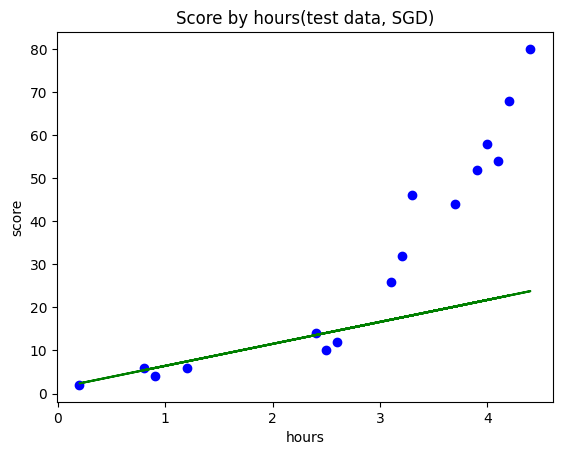

In [12]:
plt.scatter(X_train,y_train, color='blue')
plt.plot(X_train, sr.predict(X_train), color='green')
plt.title('Score by hours(test data, SGD)')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [14]:
p = np.array([[1, 2, 3], [4, 5, 6]])
print("Original array:\n", p)
print("Shape:", p.shape)

Original array:
 [[1 2 3]
 [4 5 6]]
Shape: (2, 3)


In [15]:
p = p.reshape(-1)
print("\nReshaped array:\n", p)
print("Shape:", p.shape)


Reshaped array:
 [1 2 3 4 5 6]
Shape: (6,)


In [16]:
p = p.reshape(-1, 2)
print("\nReshaped array:\n", p)
print("Shape:", p.shape)


Reshaped array:
 [[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)


In [17]:
p = p.reshape(-1, 2)
print("\nReshaped array:\n", p)
print("Shape:", p.shape)


Reshaped array:
 [[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('./dataset/LogisticRegressionData.csv')
dataset.head()

,hour,pass
0,0.5,0
1,1.2,0
2,1.8,0
3,2.4,0
4,2.6,0


In [19]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [21]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
print(classifier.classes_)

[0 1]


In [23]:
classifier.predict([[6]])

array([1])

In [24]:
classifier.predict_proba([[6]])

array([[0.141483, 0.858517]])

In [25]:
classifier.predict([[4]])

array([0])

In [26]:
classifier.predict_proba([[4]])

array([[0.62497682, 0.37502318]])

In [27]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 1, 1])

In [28]:
y_test

array([1, 0, 1, 0])

In [29]:
X_test

array([[ 8.6],
       [ 1.2],
       [10. ],
       [ 4.5]])

In [30]:
classifier.score(X_test, y_test)

0.75

In [31]:
X_range = np.arange(min(X), max(X), 0.1)
X_range

C:\Users\human-31\AppData\Local\Temp\ipykernel_7948\3009068081.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_range = np.arange(min(X), max(X), 0.1)


array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7,
       1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ,
       3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3,
       4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6,
       5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9,
       7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2,
       8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. , 9.1, 9.2, 9.3, 9.4, 9.5,
       9.6, 9.7, 9.8, 9.9])

In [32]:
p = 1/(1+ np.exp(-(classifier.coef_ * X_range + classifier.intercept_)))
p

array([[0.01035583, 0.01161118, 0.0130167 , 0.01458984, 0.01634996,
        0.01831847, 0.02051904, 0.02297778, 0.0257234 , 0.02878743,
        0.03220437, 0.03601184, 0.04025075, 0.04496534, 0.05020326,
        0.05601555, 0.06245651, 0.06958349, 0.07745655, 0.08613794,
        0.09569142, 0.10618136, 0.1176716 , 0.13022408, 0.14389721,
        0.15874395, 0.17480973, 0.19213011, 0.21072838, 0.23061305,
        0.25177552, 0.27418791, 0.29780133, 0.32254464, 0.348324  ,
        0.37502318, 0.40250484, 0.43061281, 0.45917517, 0.4880083 ,
        0.51692146, 0.54572176, 0.57421932, 0.60223222, 0.62959096,
        0.65614237, 0.6817526 , 0.70630918, 0.72972211, 0.75192414,
        0.77287004, 0.79253536, 0.81091459, 0.82801892, 0.84387392,
        0.858517  , 0.87199503, 0.88436205, 0.89567719, 0.90600282,
        0.91540298, 0.923942  , 0.93168343, 0.9386892 , 0.94501893,
        0.95072949, 0.95587461, 0.96050477, 0.96466704, 0.96840509,
        0.97175925, 0.97476661, 0.97746114, 0.97

In [34]:
X_range.shape

(95,)

In [37]:
p = p.reshape(-1)
p.shape

(95,)

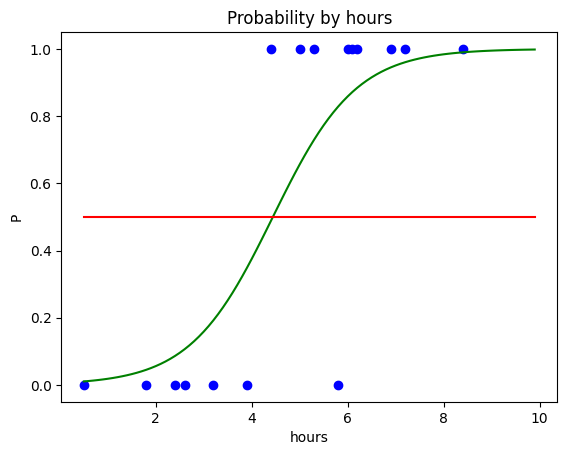

In [39]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red') # y축에 일정한 값인 0.5를 유지하는 직선
plt.title('Probability by hours')
plt.xlabel('hours')
plt.ylabel('P')
plt.show()

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [42]:
iris = load_iris()
X = iris.data  # 특징 (꽃잎, 꽃받침 길이/너비)
y = iris.target  # 품종 (0: Setosa, 1: Versicolor, 2: Virginica)
feature_names = iris.feature_names # 특징 이름 가져오기
target_names = iris.target_names # target 이름 가져오기

In [43]:
# Pandas DataFrame 생성 및 출력
df = pd.DataFrame(X, columns=feature_names)  # feature_names 리스트의 값을 순서대로 매핑하여 열 이름을 설정
df['target'] = y  # 품종 레이블 추가
df['target_name'] = df['target'].apply(lambda x: target_names[x])  # 품종 이름 추가

print("Iris Data (Head 5):")
print(df.head())
print("\n")

Iris Data (Head 5):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  




In [44]:
# 2. 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [45]:
# 3. KNN 모델 생성 및 학습
k = 5  # K 값 설정 (이웃의 수)
knn = KNeighborsClassifier(n_neighbors=k) # 모델 생성
knn.fit(X_train, y_train) # 훈련 데이터로 모델 학습

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
y_pred = knn.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred) # 정확도 계산
print(f"Accuracy: {accuracy:.4f}") # 결과 출력

Accuracy: 1.0000


In [ ]:
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # 새로운 데이터 (꽃잎, 꽃받침 길이/너비)
prediction = knn.predict(new_data)
print(f"New data prediction: {iris.target_names[prediction[0]]}") # 예측 결과 출력

New data prediction: setosa


In [51]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  # Confusion matrix 시각화를 위해 추가

In [52]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [53]:
# Pandas DataFrame 생성
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_names'] = [target_names[i] for i in y] # target 이름 추가

In [54]:
# 데이터프레임 출력 (처음 5행)
print("DataFrame Sample:")
print(df.head())

DataFrame Sample:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  


In [55]:
# 데이터 분할 (훈련 세트 80%, 테스트 세트 20%) cf. stratify=y: 데이터 분할 시 클래스 불균형 해결(클래스 비율 유지하면서 훈련, 테스트 데이터셋 분리)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [56]:
# Random Forest 모델 생성
# 하이퍼파라미터 튜닝을 위해 GridSearchCV 사용
param_grid = {
    'n_estimators': [50, 100, 200],  # 트리의 개수
    'max_depth': [4, 6, 8],       # 트리의 최대 깊이
    'min_samples_split': [2, 4],  # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2]    # 리프 노드에 있어야 하는 최소 샘플 수
}

In [57]:
rf_model = RandomForestClassifier(random_state=42)  # Random Forest 모델 초기화
# 교차 검증 cv =3 : 훈련 데이터를 3개의 FOLD(묶음)으로 나누어서 두개를 훈련, 나머지는 검증 용도로 활용
# 교차 검증은 최적의 하이퍼 파라미터 값을 찾기 위해서 사용됨
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy')

In [58]:
grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 4], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [59]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [61]:
best_rf_model = grid_search.best_estimator_

In [62]:
y_pred = best_rf_model.predict(X_test)

In [63]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [64]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



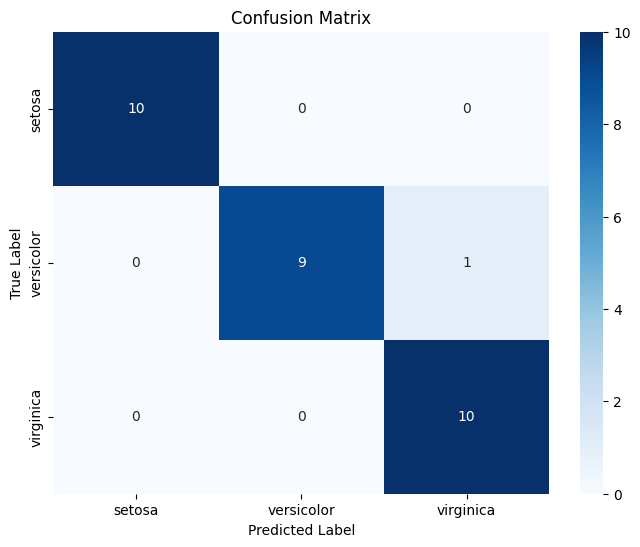

In [65]:
# 혼동 행렬 (Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
# annot=True : 각 셀안의 숫자값을 표시, fmt="d" : 숫자값을 정수형태로 표시, cmap="Blues" : 색상값은 블루
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

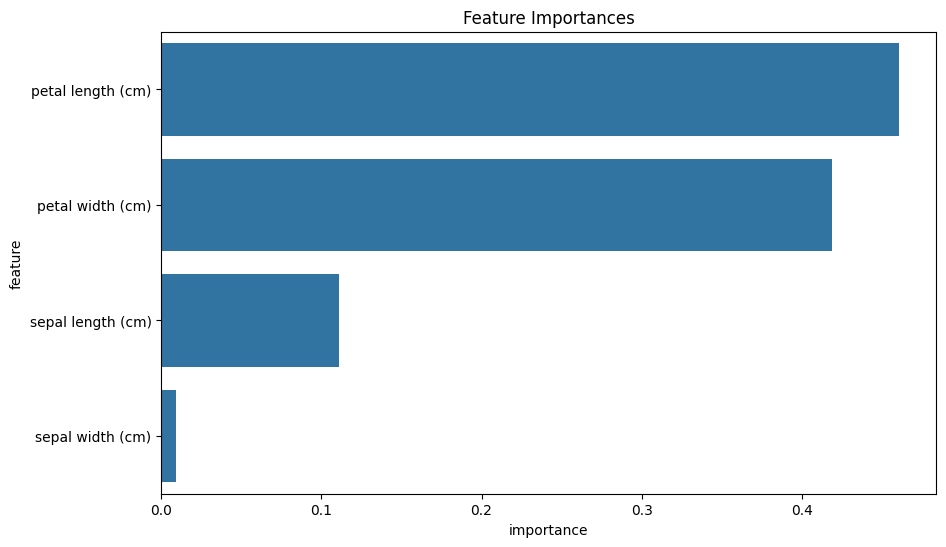

In [66]:
# Feature Importance 시각화
feature_importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.show()

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  # 텍스트 데이터를 숫자로 변환 (TF-IDF 벡터화)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [68]:
# 1. 데이터 불러오기
data = pd.read_csv('./dataset/spam.csv', encoding='ISO-8859-1')  # encoding 방식 : utf-8(범용성), ISO-8859-1(서유럽), CP949(한글)

# 데이터 내용 미리보기 (처음 5개 행 출력)
print("Spam Data (First 5 rows):")
print(data.head())
print("\n")


data = data[['v1', 'v2']]  # 필요한 열만 선택
data.columns = ['label', 'text']  # 열 이름 변경

Spam Data (First 5 rows):
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  




In [69]:
# 2. 데이터 전처리
data['label'] = data['label'].map({'ham': 0, 'spam': 1})  # 레이블을 숫자로 변환, map함수: 열의 각 값을 다른 값으로 변환하는 데 사용
data.dropna(inplace=True)  # 결측치 제거

In [70]:
# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

In [71]:
# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english') # stop_words: 불필요한 영어 단어(예: "the", "is", "and" 등)를 자동으로 제거
X_train_tfidf = vectorizer.fit_transform(X_train)   # fit: 학습 데이터의 중요한 통계정보(단어빈도수)학습, transform: 숫자 벡터로 변환
X_test_tfidf = vectorizer.transform(X_test)


In [72]:
# 5. 모델 학습
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [73]:
# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9668161434977578

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [74]:
# 7. 샘플 테스트
sample_text = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
               "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
               "Hey, are we meeting for lunch tomorrow?"]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text: {text} => {'Spam' if label == 1 else 'Ham'}")

Text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text: Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text: Hey, are we meeting for lunch tomorrow? => Ham


In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [76]:
# 1. 데이터 불러오기
data = pd.read_csv('./dataset/spam.csv', encoding='ISO-8859-1')
data = data[['v1', 'v2']]  # 필요한 열만 선택
data.columns = ['label', 'text']  # 열 이름 변경

In [77]:
# 2. 데이터 전처리
data['label'] = data['label'].map({'ham': 0, 'spam': 1})  # 레이블을 숫자로 변환
data.dropna(inplace=True)  # 결측치 제거

In [78]:
# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

In [79]:
# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [80]:
# 5. SVM 모델 학습
model = SVC(kernel='linear', random_state=42)  # SVM 모델 생성 (linear : 직선, 평면, 초평면)
model.fit(X_train_tfidf, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [81]:
# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.979372197309417

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [82]:
# 7. 샘플 테스트
sample_text = [
    "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
    "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
    "Hey, are we meeting for lunch tomorrow?"
]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text: {text} => {'Spam' if label == 1 else 'Ham'}")

Text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text: Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text: Hey, are we meeting for lunch tomorrow? => Ham
